# Model Construction

In [57]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [58]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VAL_CSV = DATA_DIR / "validate_split.csv"
TEST_CSV = DATA_DIR / "test_split.csv"

CLASSES = ["malignant", "benign", "normal"]
label_map = {c: i for i, c in enumerate(CLASSES)}

## Retrive images 

python3(20746) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Using device: mps
Total: 780 | Train: 624 | Test: 156
Fold 1: train 499 | val 125
Fold 2: train 499 | val 125
Fold 3: train 499 | val 125
Fold 4: train 499 | val 125
Fold 5: train 500 | val 124


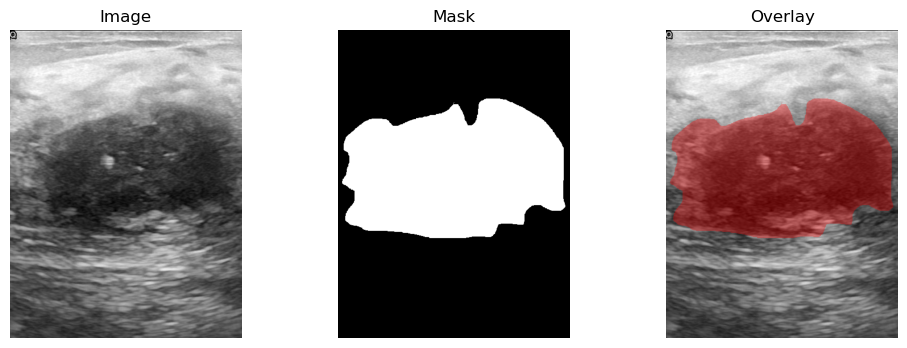

Saved train_split.csv and test_split.csv to ../data/


In [59]:
# Pull in all preprocessing and dataset pipeline helpers from the other notebook.
# This keeps this notebook focused purely on model architecture and evaluation.
%run msb_data_preprocessing.ipynb

In [60]:
BATCH_SIZE = 32
USE_MASKS = True

transform, train_transform = get_default_transforms()

datasets, loaders = prepare_data_pipeline(
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    label_map,
    batch_size=BATCH_SIZE,
    use_masks=USE_MASKS,
    transform=transform,
    train_transform=train_transform,
)

train_dataset = datasets['train']
val_dataset = datasets['val']
test_dataset = datasets['test']

train_loader = loaders['train']
val_loader = loaders['val']
test_loader = loaders['test']


## CNN model for ML

In [61]:
class BreastUS_CNN(nn.Module):
    def __init__(self, num_classes=3, input_channels=2):
        super(BreastUS_CNN, self).__init__()
        self.input_channels = input_channels
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [62]:
train_df = pd.read_csv(TRAIN_CSV)
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)

class_to_idx = {name: idx for idx, name in enumerate(CLASSES)}
standard_weights = np.zeros(len(CLASSES))
for class_name, count in class_counts.items():
    idx = class_to_idx[class_name]
    standard_weights[idx] = total_samples / (len(CLASSES) * count)

normal_idx = class_to_idx['normal']
malignant_idx = class_to_idx['malignant']

class_weights = standard_weights.copy()
class_weights[normal_idx] = standard_weights[normal_idx] * 1.6
class_weights[malignant_idx] = standard_weights[malignant_idx] * 1.3

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = FocalLoss(alpha=class_weights_tensor, gamma=1.5, reduction='mean')

In [63]:
def compute_correct_labels(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = torch.sum(preds == labels).item()
    total = labels.size(0)
    return correct, total


In [64]:
def training_loop(model, optimizer, scheduler, num_epochs, train_loader, val_loader, test_loader, class_names):
    train_losses, val_losses, test_losses = [], [], []
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_class_correct = {i: 0 for i in range(len(class_names))}
        val_class_total = {i: 0 for i in range(len(class_names))}
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
                for i in range(len(y)):
                    label = y[i].item()
                    pred = preds[i].item()
                    val_class_total[label] += 1
                    if label == pred:
                        val_class_correct[label] += 1

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        val_class_accs = []
        for i in range(len(class_names)):
            if val_class_total.get(i, 0) > 0:
                val_class_accs.append(val_class_correct[i] / val_class_total[i])
        
        if len(val_class_accs) == len(class_names):
            min_class_acc = min(val_class_accs)
            balanced_score = val_acc * (0.7 + 0.3 * min_class_acc)
        else:
            balanced_score = val_acc
        
        if balanced_score > best_val_acc:
            best_val_acc = balanced_score
            best_model_state = model.state_dict().copy()

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        test_losses.append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, test_losses


In [66]:
input_channels = 2 if USE_MASKS else 1
model = BreastUS_CNN(num_classes=3, input_channels=input_channels).to(device)

initial_lr = 5e-4
optimizer = optim.Adam(model.parameters(), lr=initial_lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, verbose=False, min_lr=1e-6
)

EPOCHS = 50
train_losses, val_losses, test_losses = training_loop(
    model, optimizer, scheduler, EPOCHS, train_loader, val_loader, test_loader, CLASSES)

Epoch [1/50] Train Loss: 1.0117 | Val Loss: 1.6164 | Test Loss: 1.6517
Epoch [2/50] Train Loss: 0.9187 | Val Loss: 1.1895 | Test Loss: 1.2825
Epoch [3/50] Train Loss: 0.9032 | Val Loss: 1.7902 | Test Loss: 1.5879
Epoch [4/50] Train Loss: 0.8627 | Val Loss: 1.8689 | Test Loss: 1.7114
Epoch [5/50] Train Loss: 0.8230 | Val Loss: 2.2114 | Test Loss: 1.9521
Epoch [6/50] Train Loss: 0.6948 | Val Loss: 1.3122 | Test Loss: 1.2319
Epoch [7/50] Train Loss: 0.7191 | Val Loss: 3.0486 | Test Loss: 2.8802
Epoch [8/50] Train Loss: 0.6820 | Val Loss: 3.0347 | Test Loss: 2.8893
Epoch [9/50] Train Loss: 0.5699 | Val Loss: 5.9091 | Test Loss: 5.5852
Epoch [10/50] Train Loss: 0.5132 | Val Loss: 2.1012 | Test Loss: 1.9017
Epoch [11/50] Train Loss: 0.4422 | Val Loss: 2.4425 | Test Loss: 2.3071
Epoch [12/50] Train Loss: 0.3777 | Val Loss: 0.6879 | Test Loss: 0.6186
Epoch [13/50] Train Loss: 0.3959 | Val Loss: 1.6750 | Test Loss: 1.5671
Epoch [14/50] Train Loss: 0.3952 | Val Loss: 2.1291 | Test Loss: 1.9872
E

All the losses are decreasing rapidly, but the accuracy is still low.  

In [67]:
def evaluate_model(model, test_loader, device, class_names):
    """Evaluate model on test set and return accuracy and predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    # Per-class statistics
    class_correct = {i: 0 for i in range(len(class_names))}
    class_total = {i: 0 for i in range(len(class_names))}
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            correct += (preds == y).sum().item()
            total += y.size(0)
            
            # Count per-class accuracy
            for i in range(len(y)):
                label = y[i].item()
                pred = preds[i].item()
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1
    
    accuracy = correct / total
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("\nPer-class Test Accuracy:")
    for i, class_name in enumerate(class_names):
        if class_total[i] > 0:
            class_acc = class_correct[i] / class_total[i] * 100
            print(f"  {class_name}: {class_correct[i]}/{class_total[i]} ({class_acc:.2f}%)")
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate the trained model
test_preds, test_labels = evaluate_model(model, test_loader, device, CLASSES)



Overall Test Accuracy: 75.00%

Per-class Test Accuracy:
  malignant: 40/42 (95.24%)
  benign: 50/87 (57.47%)
  normal: 27/27 (100.00%)


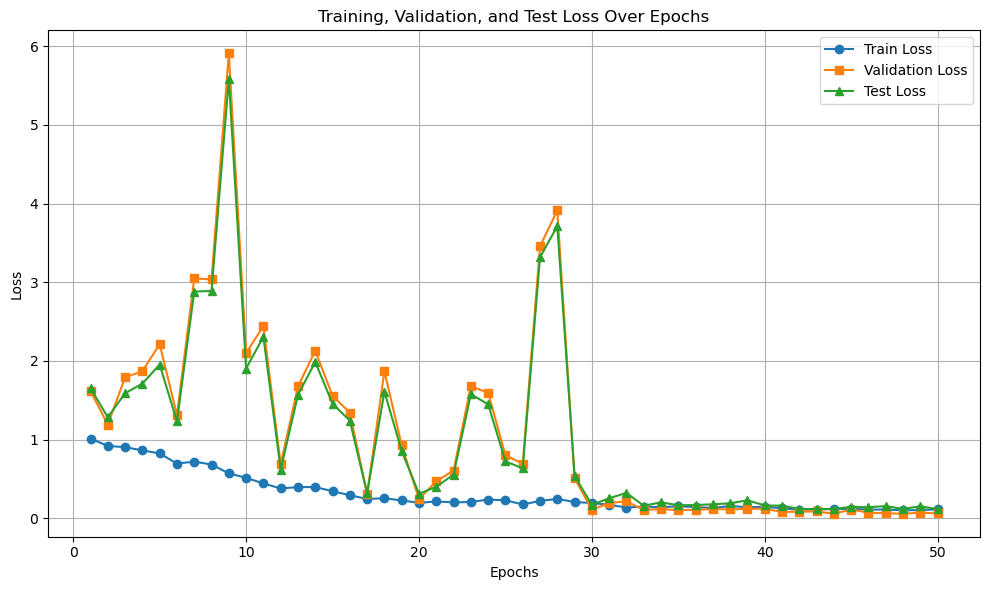

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label='Validation Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, '^-', label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training, Validation, and Test Loss Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

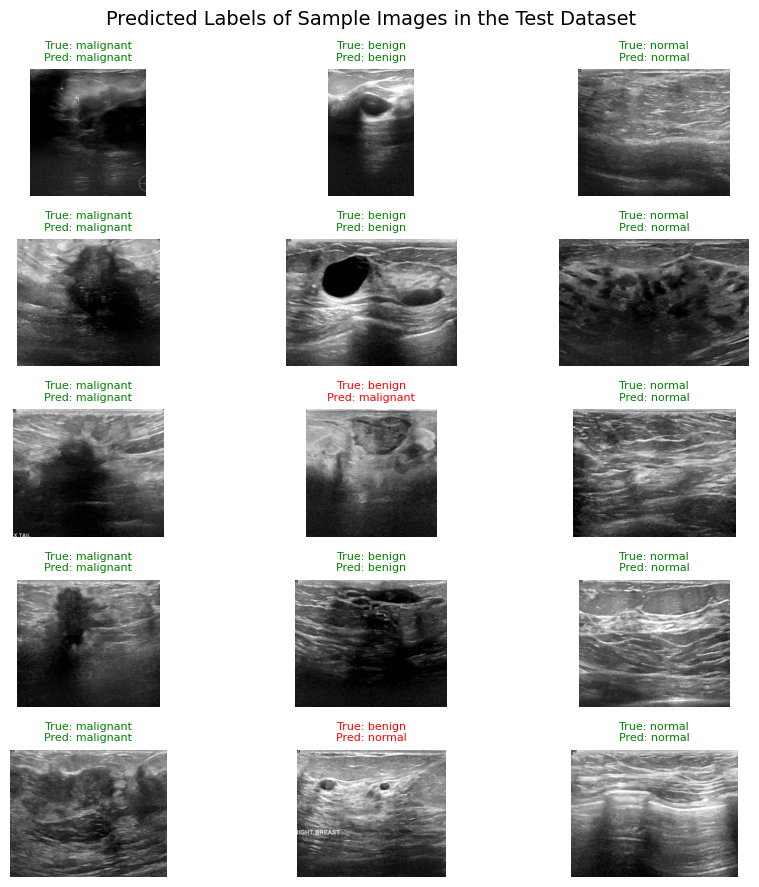

In [69]:
model.eval()
test_df = pd.read_csv(TEST_CSV)

num_samples_per_class = 5
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(num_samples_per_class, len(CLASSES))

reverse_label_map = {v: k for k, v in label_map.items()}

for class_idx, class_name in enumerate(CLASSES):
    class_images = test_df[test_df['label'] == class_name].head(num_samples_per_class)
    
    for row_idx, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['path']
        image = Image.open(img_path).convert('RGB')
        
        if USE_MASKS:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = image.convert('L')
            
            img_gray = img_gray.resize((224, 224), Image.LANCZOS)
            mask_pil = mask_pil.resize((224, 224), Image.NEAREST)
            
            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)
            
            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)
            
            input_tensor = torch.cat([img_gray_t, mask_t], dim=0).unsqueeze(0).to(device)
        else:
            img_gray = image.convert('L')
            input_tensor = transform(img_gray).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
        predicted_class = reverse_label_map[predicted.item()]
        true_label = row['label']
        
        ax = fig.add_subplot(gs[row_idx, class_idx])
        ax.imshow(image)
        ax.axis('off')
        
        color = 'green' if predicted_class == true_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {predicted_class}', 
                     color=color, fontsize=8)

plt.suptitle('Predicted Labels of Sample Images in the Test Dataset', fontsize=14)
plt.tight_layout()
plt.show()


The model is doing really well on normal images, but it still need to correctly differentiate between Malignant and Benign tumors. 